# Non-stationary Example: Changepoint Kernel vs Baseline Matern

This notebook demonstrates when a changepoint kernel is useful.

Workflow:
1. Create a synthetic time-series with a true regime shift.
2. Run exploratory visualizations to diagnose non-stationarity.
3. Fit two GP models using GPArchitect builders:
   - Baseline: stationary Matern 5/2 kernel
   - Non-stationary: Changepoint kernel
4. Compare validation metrics and predictive plots.

In [12]:
from __future__ import annotations

import math
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

repo_root = pathlib.Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from gparchitect.builders.builder import build_model_from_dsl
from gparchitect.dsl.schema import (
    CompositionType,
    FeatureGroupSpec,
    GPSpec,
    KernelSpec,
    KernelType,
    ModelClass,
    )
from gparchitect.fitting.fitter import fit_and_validate

torch.set_default_dtype(torch.double)
torch.manual_seed(21)
np.random.seed(21)

In [13]:
# Synthetic dataset with a strong mean changepoint around t=0.45
n = 240
t = np.linspace(0.0, 1.0, n)
cp_true = 0.45

# Regime 1: oscillatory, centered near zero
y_left = 0.35 * np.sin(10.0 * math.pi * t)

# Regime 2: shifted level and strong downward trend
y_right = 1.25 - 3.2 * (t - cp_true) + 0.15 * np.cos(6.0 * math.pi * t)

signal = np.where(t < cp_true, y_left, y_right)

# Keep noise homoskedastic so the effect is primarily mean-regime change
noise_std = 0.08
noise = np.random.normal(0.0, noise_std, size=n)
y = signal + noise

df = pd.DataFrame({
    "time": t,
    "target": y,
    "signal_true": signal,
})
df.head()

,time,target,signal_true
0,0.000000,-0.004157,0.000000
1,0.004184,0.036979,0.045874
2,0.008368,0.174301,0.090957
3,0.012552,0.033931,0.134470
4,0.016736,0.235295,0.175664


Why changepoint may help: the mean function changes sharply around t~0.45.


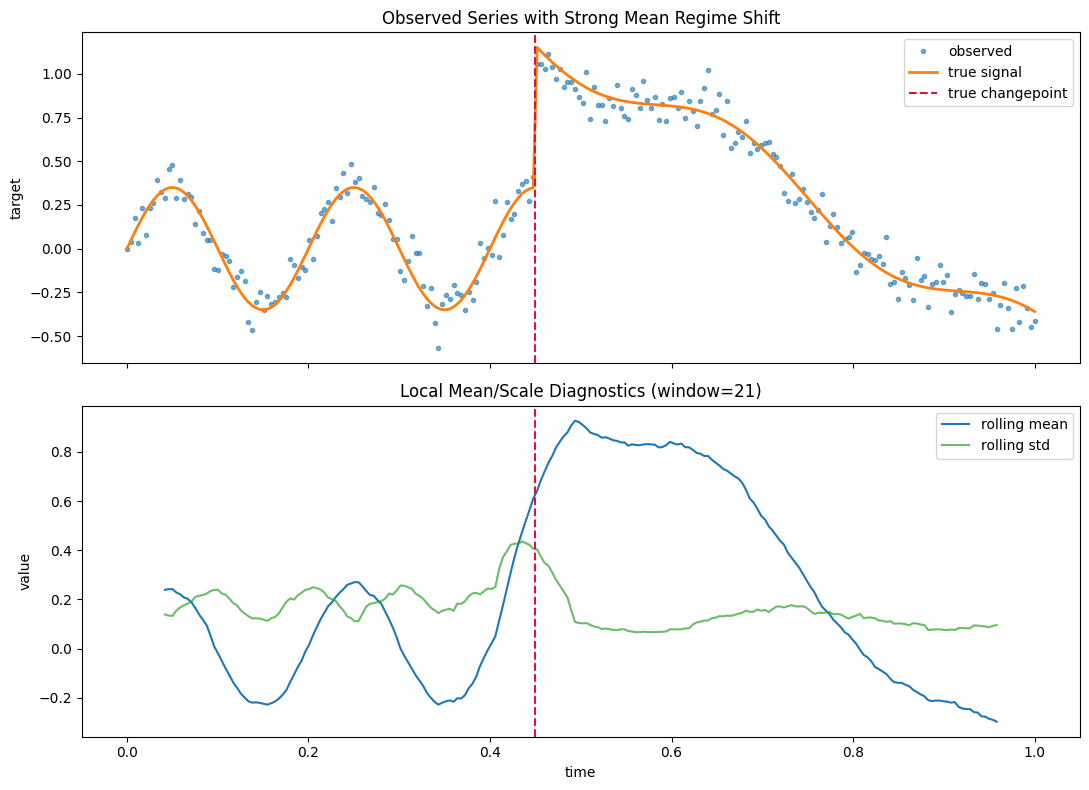

In [14]:
# Exploratory visualization: strong mean-regime change before/after changepoint
window = 21
rolling_mean = df["target"].rolling(window=window, center=True).mean()
rolling_std = df["target"].rolling(window=window, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(df["time"], df["target"], ".", alpha=0.6, label="observed")
axes[0].plot(df["time"], df["signal_true"], linewidth=2, label="true signal")
axes[0].axvline(cp_true, color="crimson", linestyle="--", label="true changepoint")
axes[0].set_title("Observed Series with Strong Mean Regime Shift")
axes[0].set_ylabel("target")
axes[0].legend()

axes[1].plot(df["time"], rolling_mean, color="tab:blue", label="rolling mean")
axes[1].plot(df["time"], rolling_std, color="tab:green", alpha=0.7, label="rolling std")
axes[1].axvline(cp_true, color="crimson", linestyle="--")
axes[1].set_title(f"Local Mean/Scale Diagnostics (window={window})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("value")
axes[1].legend()
plt.tight_layout()

print("Why changepoint may help: the mean function changes sharply around t~0.45.")

In [15]:
# Time-aware split: first 70% train, last 30% test
split_idx = int(0.7 * n)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

train_X = torch.tensor(train_df[["time"]].values, dtype=torch.double)
train_Y = torch.tensor(train_df[["target"]].values, dtype=torch.double)
test_X = torch.tensor(test_df[["time"]].values, dtype=torch.double)
test_Y = torch.tensor(test_df[["target"]].values, dtype=torch.double)

print(train_X.shape, test_X.shape)

torch.Size([168, 1]) torch.Size([72, 1])


In [16]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def nll_gaussian(y_true: np.ndarray, mean: np.ndarray, var: np.ndarray, eps: float = 1e-8) -> float:
    var_safe = np.maximum(var, eps)
    return float(np.mean(0.5 * np.log(2.0 * np.pi * var_safe) + 0.5 * ((y_true - mean) ** 2) / var_safe))


def fit_predict(spec: GPSpec, train_X: torch.Tensor, train_Y: torch.Tensor, test_X: torch.Tensor) -> dict:
    model = build_model_from_dsl(spec, train_X, train_Y)
    fit_result = fit_and_validate(model, train_X, train_Y)
    if not fit_result.success:
        raise RuntimeError(f"Fit failed: {fit_result.error_message}")

    fitted = fit_result.model
    fitted.eval()
    fitted.likelihood.eval()

    with torch.no_grad():
        posterior = fitted.posterior(test_X)
        mean = posterior.mean.squeeze(-1).cpu().numpy()
        var = posterior.variance.squeeze(-1).cpu().numpy()

    return {"model": fitted, "mean": mean, "var": var}

In [ ]:
baseline_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
        )
    ],
    input_dim=1,
    output_dim=1,
)

changepoint_spec = GPSpec(
    model_class=ModelClass.SINGLE_TASK_GP,
    feature_groups=[
        FeatureGroupSpec(
            name="time",
            feature_indices=[0],
            kernel=KernelSpec(
                kernel_type=KernelType.CHANGEPOINT,
                changepoint_location=0.45,
                changepoint_steepness=0.08,
                children=[
                    KernelSpec(kernel_type=KernelType.MATERN_52),
                    KernelSpec(
                        kernel_type=KernelType.MATERN_52,
                        composition=CompositionType.ADDITIVE,
                        children=[
                            KernelSpec(kernel_type=KernelType.LINEAR),
                            KernelSpec(kernel_type=KernelType.MATERN_52),
                        ],
                    ),
                ],
            ),
        )
    ],
    input_dim=1,
    output_dim=1,
)

In [18]:
baseline = fit_predict(baseline_spec, train_X, train_Y, test_X)
cp_model = fit_predict(changepoint_spec, train_X, train_Y, test_X)

y_true = test_Y.squeeze(-1).cpu().numpy()

metrics = pd.DataFrame(
    [
        {
            "model": "Matern52 baseline",
            "RMSE": rmse(y_true, baseline["mean"]),
            "MAE": mae(y_true, baseline["mean"]),
            "NLL": nll_gaussian(y_true, baseline["mean"], baseline["var"]),
        },
        {
            "model": "Changepoint kernel",
            "RMSE": rmse(y_true, cp_model["mean"]),
            "MAE": mae(y_true, cp_model["mean"]),
            "NLL": nll_gaussian(y_true, cp_model["mean"], cp_model["var"]),
        },
    ]
).sort_values("RMSE")

metrics

,model,RMSE,MAE,NLL
1,Changepoint kernel,0.309018,0.271367,0.047786
0,Matern52 baseline,0.919350,0.840994,2.398147


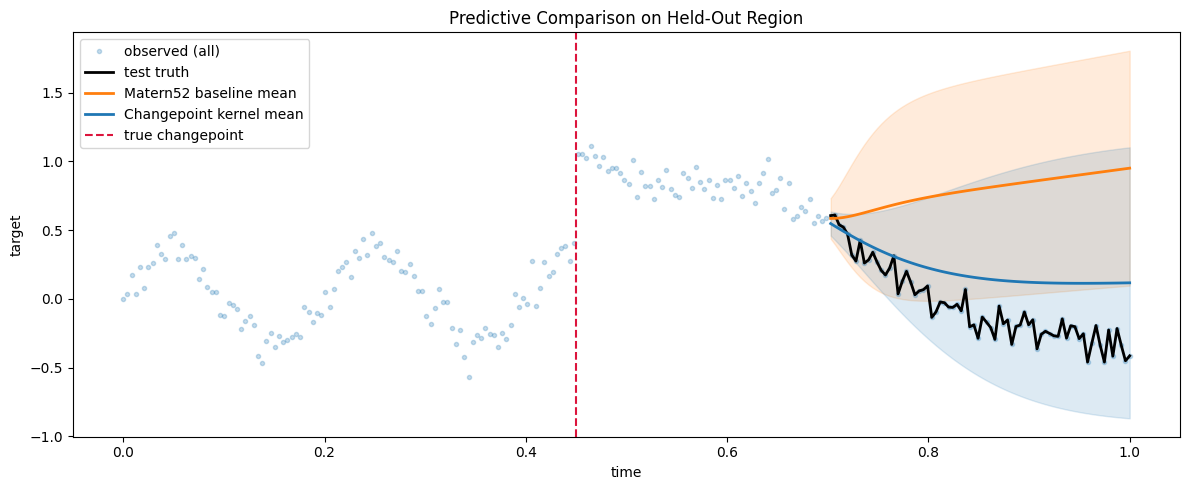

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["time"], df["target"], ".", alpha=0.25, label="observed (all)")
ax.plot(test_df["time"], y_true, color="black", linewidth=2, label="test truth")

for name, result, color in [
    ("Matern52 baseline", baseline, "tab:orange"),
    ("Changepoint kernel", cp_model, "tab:blue"),
]:
    mean = result["mean"]
    std = np.sqrt(np.maximum(result["var"], 1e-9))
    x = test_df["time"].to_numpy()
    ax.plot(x, mean, color=color, linewidth=2, label=f"{name} mean")
    ax.fill_between(x, mean - 1.96 * std, mean + 1.96 * std, color=color, alpha=0.15)

ax.axvline(cp_true, color="crimson", linestyle="--", linewidth=1.5, label="true changepoint")
ax.set_title("Predictive Comparison on Held-Out Region")
ax.set_xlabel("time")
ax.set_ylabel("target")
ax.legend(loc="best")
plt.tight_layout()

In [9]:
# Optional inspection of learned changepoint parameters
cp_kernel = cp_model["model"].covar_module.base_kernel
print("Learned changepoint location:", float(cp_kernel.location.detach().cpu()))
print("Learned changepoint steepness:", float(cp_kernel.steepness.detach().cpu()))

Learned changepoint location: 0.4477075216216682
Learned changepoint steepness: 3.698990891609557e-06


## Multi-Seed Robustness Check

This section reruns the same synthetic experiment across multiple random seeds and compares baseline vs changepoint performance distributions.

We summarize:
- RMSE, MAE, and Gaussian NLL
- 95% predictive interval coverage
- Win rates for changepoint vs baseline across seeds

Per-seed results (first 5 rows):


,seed,baseline_RMSE,cp_RMSE,delta_RMSE,baseline_MAE,cp_MAE,delta_MAE,baseline_NLL,cp_NLL,delta_NLL,baseline_cov95,cp_cov95,delta_cov95
0,0,0.439888,0.431239,-0.008649,0.386345,0.376860,-0.009484,0.545538,0.288747,-0.256791,0.972222,0.986111,0.013889
1,1,0.467177,0.418023,-0.049154,0.424936,0.380719,-0.044217,0.598557,0.768097,0.169539,0.986111,0.888889,-0.097222
2,2,0.458537,0.383334,-0.075203,0.417933,0.350561,-0.067372,0.606167,0.700581,0.094414,0.986111,0.944444,-0.041667
3,3,0.453609,0.362293,-0.091316,0.413454,0.336999,-0.076456,0.527171,0.531406,0.004235,1.000000,0.861111,-0.138889
4,4,0.425533,0.146215,-0.279318,0.377215,0.117888,-0.259327,0.425659,0.109753,-0.315905,1.000000,0.972222,-0.027778



Aggregate summary across seeds:


,Metric,Baseline Mean,Changepoint Mean,Delta Mean (CP - Baseline)
0,RMSE,0.452341,0.371102,-0.081239
1,MAE,0.404625,0.333598,-0.071027
2,NLL,0.539808,1.276461,0.736653
3,Cov95,0.993056,0.902083,-0.090972



Changepoint win rates across seeds:


,Criterion,Win Rate
0,CP better RMSE (lower),0.8
1,CP better MAE (lower),0.8
2,CP better NLL (lower),0.6
3,CP better Cov95 (higher),0.1


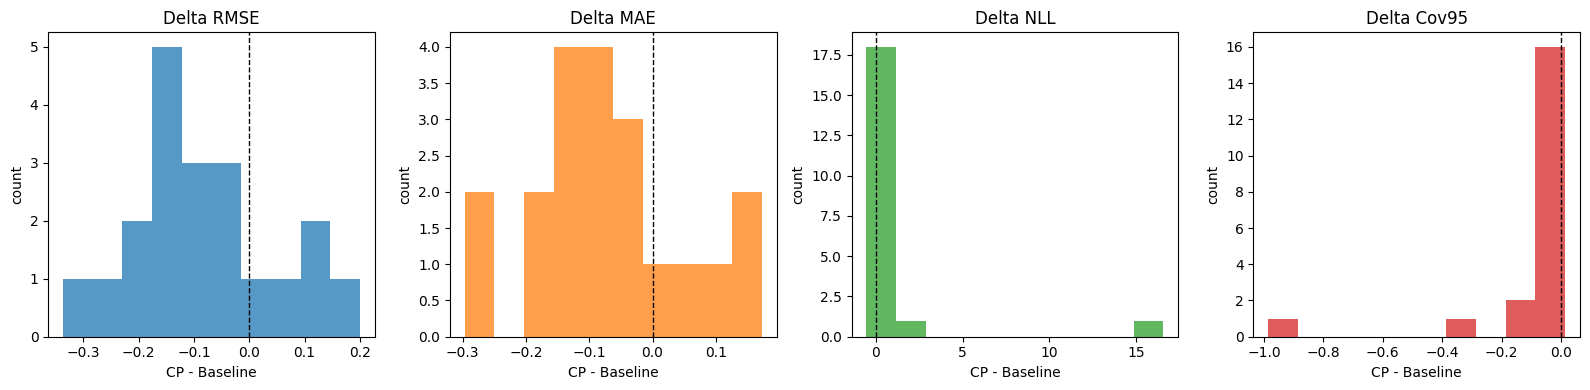

In [10]:
# Multi-seed robustness evaluation with strong mean changepoint and constant noise
seed_list = list(range(20))
records = []

for seed in seed_list:
    np.random.seed(seed)
    torch.manual_seed(seed)

    n_local = 240
    t_local = np.linspace(0.0, 1.0, n_local)
    cp_local = 0.45

    y_left_local = 0.35 * np.sin(10.0 * math.pi * t_local)
    y_right_local = 1.25 - 3.2 * (t_local - cp_local) + 0.15 * np.cos(6.0 * math.pi * t_local)
    signal_local = np.where(t_local < cp_local, y_left_local, y_right_local)

    noise_local = np.random.normal(0.0, 0.08, size=n_local)
    y_local = signal_local + noise_local

    split_local = int(0.7 * n_local)
    train_X_local = torch.tensor(t_local[:split_local, None], dtype=torch.double)
    train_Y_local = torch.tensor(y_local[:split_local, None], dtype=torch.double)
    test_X_local = torch.tensor(t_local[split_local:, None], dtype=torch.double)
    test_Y_local = torch.tensor(y_local[split_local:, None], dtype=torch.double)
    y_true_local = test_Y_local.squeeze(-1).cpu().numpy()

    baseline_spec_local = GPSpec(
        model_class=ModelClass.SINGLE_TASK_GP,
        feature_groups=[
            FeatureGroupSpec(
                name="time",
                feature_indices=[0],
                kernel=KernelSpec(kernel_type=KernelType.MATERN_52),
            )
        ],
        input_dim=1,
        output_dim=1,
    )

    cp_spec_local = GPSpec(
        model_class=ModelClass.SINGLE_TASK_GP,
        feature_groups=[
            FeatureGroupSpec(
                name="time",
                feature_indices=[0],
                kernel=KernelSpec(
                    kernel_type=KernelType.CHANGEPOINT,
                    changepoint_location=0.45,
                    changepoint_steepness=0.08,
                    children=[
                        KernelSpec(kernel_type=KernelType.MATERN_52),
                        KernelSpec(
                            kernel_type=KernelType.MATERN_52,
                            composition=CompositionType.ADDITIVE,
                            children=[
                                KernelSpec(kernel_type=KernelType.LINEAR),
                                KernelSpec(kernel_type=KernelType.MATERN_52),
                            ],
                        ),
                    ],
                ),
            )
        ],
        input_dim=1,
        output_dim=1,
    )

    baseline_local = fit_predict(baseline_spec_local, train_X_local, train_Y_local, test_X_local)
    cp_local_result = fit_predict(cp_spec_local, train_X_local, train_Y_local, test_X_local)

    baseline_rmse = rmse(y_true_local, baseline_local["mean"])
    cp_rmse = rmse(y_true_local, cp_local_result["mean"])
    baseline_mae = mae(y_true_local, baseline_local["mean"])
    cp_mae = mae(y_true_local, cp_local_result["mean"])
    baseline_nll = nll_gaussian(y_true_local, baseline_local["mean"], baseline_local["var"])
    cp_nll = nll_gaussian(y_true_local, cp_local_result["mean"], cp_local_result["var"])

    baseline_std = np.sqrt(np.maximum(baseline_local["var"], 1e-9))
    cp_std = np.sqrt(np.maximum(cp_local_result["var"], 1e-9))
    baseline_cover = np.mean(
        (y_true_local >= baseline_local["mean"] - 1.96 * baseline_std)
        & (y_true_local <= baseline_local["mean"] + 1.96 * baseline_std)
    )
    cp_cover = np.mean(
        (y_true_local >= cp_local_result["mean"] - 1.96 * cp_std)
        & (y_true_local <= cp_local_result["mean"] + 1.96 * cp_std)
    )

    records.append(
        {
            "seed": seed,
            "baseline_RMSE": baseline_rmse,
            "cp_RMSE": cp_rmse,
            "delta_RMSE": cp_rmse - baseline_rmse,
            "baseline_MAE": baseline_mae,
            "cp_MAE": cp_mae,
            "delta_MAE": cp_mae - baseline_mae,
            "baseline_NLL": baseline_nll,
            "cp_NLL": cp_nll,
            "delta_NLL": cp_nll - baseline_nll,
            "baseline_cov95": baseline_cover,
            "cp_cov95": cp_cover,
            "delta_cov95": cp_cover - baseline_cover,
        }
    )

robust_df = pd.DataFrame(records)

summary_table = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE", "NLL", "Cov95"],
        "Baseline Mean": [
            robust_df["baseline_RMSE"].mean(),
            robust_df["baseline_MAE"].mean(),
            robust_df["baseline_NLL"].mean(),
            robust_df["baseline_cov95"].mean(),
        ],
        "Changepoint Mean": [
            robust_df["cp_RMSE"].mean(),
            robust_df["cp_MAE"].mean(),
            robust_df["cp_NLL"].mean(),
            robust_df["cp_cov95"].mean(),
        ],
        "Delta Mean (CP - Baseline)": [
            robust_df["delta_RMSE"].mean(),
            robust_df["delta_MAE"].mean(),
            robust_df["delta_NLL"].mean(),
            robust_df["delta_cov95"].mean(),
        ],
    }
)

win_rates = pd.DataFrame(
    {
        "Criterion": [
            "CP better RMSE (lower)",
            "CP better MAE (lower)",
            "CP better NLL (lower)",
            "CP better Cov95 (higher)",
        ],
        "Win Rate": [
            (robust_df["delta_RMSE"] < 0).mean(),
            (robust_df["delta_MAE"] < 0).mean(),
            (robust_df["delta_NLL"] < 0).mean(),
            (robust_df["delta_cov95"] > 0).mean(),
        ],
    }
)

print("Per-seed results (first 5 rows):")
display(robust_df.head())

print("\nAggregate summary across seeds:")
display(summary_table)

print("\nChangepoint win rates across seeds:")
display(win_rates)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(robust_df["delta_RMSE"], bins=10, alpha=0.75, color="tab:blue")
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Delta RMSE")

axes[1].hist(robust_df["delta_MAE"], bins=10, alpha=0.75, color="tab:orange")
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delta MAE")

axes[2].hist(robust_df["delta_NLL"], bins=10, alpha=0.75, color="tab:green")
axes[2].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Delta NLL")

axes[3].hist(robust_df["delta_cov95"], bins=10, alpha=0.75, color="tab:red")
axes[3].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[3].set_title("Delta Cov95")

for ax_i in axes:
    ax_i.set_xlabel("CP - Baseline")
    ax_i.set_ylabel("count")

plt.tight_layout()

# Takeaway

Change point kernels can be helpful when the posterior mean actually changes, but it is not so effective in terms of 